<a href="https://colab.research.google.com/github/Zajecia-na-PWr-LR/lista-5-altMIchal/blob/main/ml_lab05_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **ZADANIE 1**

# **1. Analiza Eksploracyjna (EDA)**

In [3]:
import pandas as pd
import numpy as np
import time

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import AdaBoostClassifier, BaggingClassifier, GradientBoostingClassifier, StackingClassifier, VotingClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, recall_score
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression

In [4]:
data = pd.read_csv("/content/ObesityDataSet_raw_and_data_sinthetic.csv")
print(30*"-", "Opis kolumn", 30*"-")
data.info()
print("\n")

print(30*"-", "Statystyki kolumn numerycznych", 30*"-")
display(data.describe().round(2))
print("\n")

print(30*"-", "Brakujące dane", 30*"-")
display(data.isnull().sum())

------------------------------ Opis kolumn ------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2111 entries, 0 to 2110
Data columns (total 17 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Gender                          2111 non-null   object 
 1   Age                             2111 non-null   float64
 2   Height                          2111 non-null   float64
 3   Weight                          2111 non-null   float64
 4   family_history_with_overweight  2111 non-null   object 
 5   FAVC                            2111 non-null   object 
 6   FCVC                            2111 non-null   float64
 7   NCP                             2111 non-null   float64
 8   CAEC                            2111 non-null   object 
 9   SMOKE                           2111 non-null   object 
 10  CH2O                            2111 non-null   float64
 11  SCC                  

,Age,Height,Weight,FCVC,NCP,CH2O,FAF,TUE
count,2111.00,2111.00,2111.00,2111.00,2111.00,2111.00,2111.00,2111.00
mean,24.31,1.70,86.59,2.42,2.69,2.01,1.01,0.66
std,6.35,0.09,26.19,0.53,0.78,0.61,0.85,0.61
min,14.00,1.45,39.00,1.00,1.00,1.00,0.00,0.00
25%,19.95,1.63,65.47,2.00,2.66,1.58,0.12,0.00
50%,22.78,1.70,83.00,2.39,3.00,2.00,1.00,0.63
75%,26.00,1.77,107.43,3.00,3.00,2.48,1.67,1.00
max,61.00,1.98,173.00,3.00,4.00,3.00,3.00,2.00




------------------------------ Brakujące dane ------------------------------


,0
Gender,0
Age,0
Height,0
Weight,0
family_history_with_overweight,0
FAVC,0
FCVC,0
NCP,0
CAEC,0
SMOKE,0


Nie ma żadnych brakujących danych

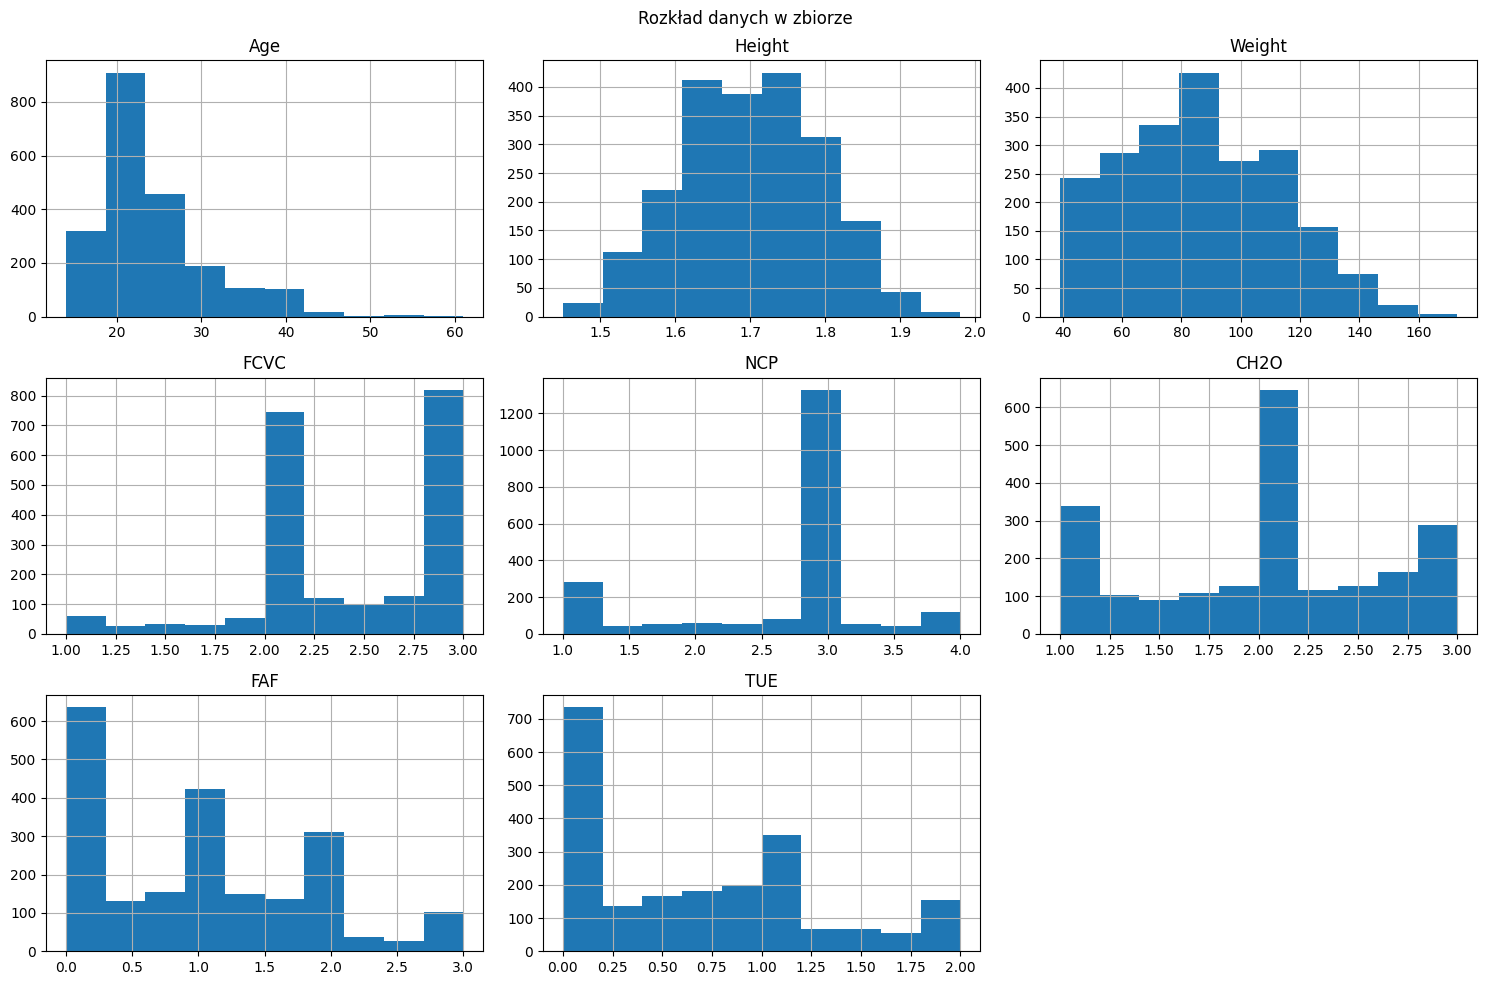

In [5]:
data.hist(figsize=(15, 10))
plt.suptitle("Rozkład danych w zbiorze")
plt.tight_layout()

Opis kolumn:

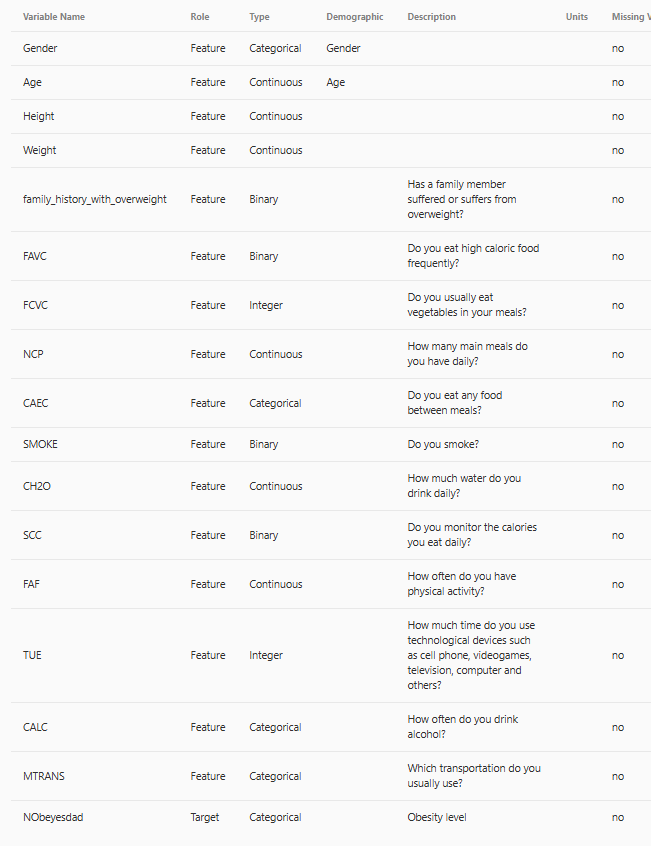

In [6]:
print(data['NObeyesdad'].value_counts())

NObeyesdad
Obesity_Type_I         351
Obesity_Type_III       324
Obesity_Type_II        297
Overweight_Level_I     290
Overweight_Level_II    290
Normal_Weight          287
Insufficient_Weight    272
Name: count, dtype: int64


Target jest zbilansowany, nie trzeba się martwić o niezbilansowane klasy

**Macierz Korelacji**

------------------------------ Macierz korelacji ------------------------------


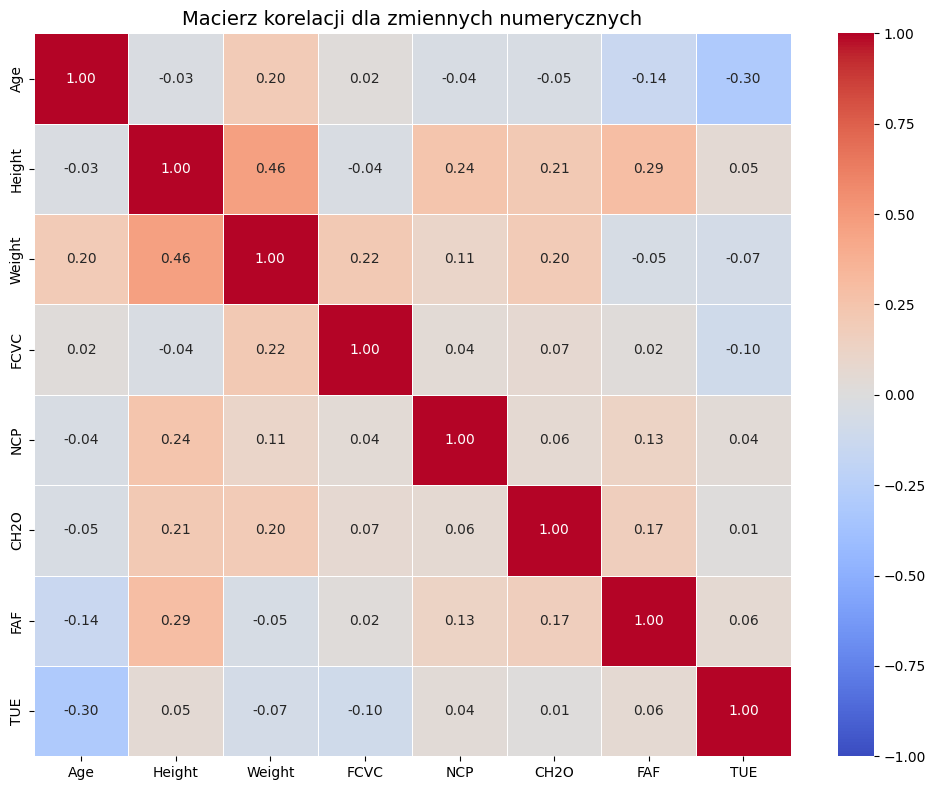

In [7]:
print(30*"-", "Macierz korelacji", 30*"-")

# Zdefiniowanie kolumn numerycznych (tych, których używałeś do skalowania)
num_cols = ['Age', 'Height', 'Weight', 'FCVC', 'NCP', 'CH2O', 'FAF', 'TUE']

# Obliczenie macierzy korelacji
corr_matrix = data[num_cols].corr()

# Rysowanie mapy ciepła (heatmap)
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5, vmin=-1, vmax=1)
plt.title("Macierz korelacji dla zmiennych numerycznych", fontsize=14)
plt.tight_layout()
plt.show()

**Preprocessing Danych**

In [8]:
X = data.drop('NObeyesdad', axis=1)
y = data['NObeyesdad']

In [9]:
X = pd.get_dummies(X, drop_first=True, dtype=int)

In [10]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [11]:
scaler = StandardScaler()
true_num_cols = ['Age', 'Height', 'Weight', 'FCVC', 'NCP', 'CH2O', 'FAF', 'TUE']

X_train[true_num_cols] = scaler.fit_transform(X_train[true_num_cols])
X_test[true_num_cols] = scaler.transform(X_test[true_num_cols])

**Funkcja walidująca model**

In [12]:
# ocena modelu poprzez użycie różnego rodzaju metryk
def evaluate_model(nazwa_modelu, model, X_test, y_test):
    print(f"\n{'='*40}")
    print(f"RAPORT DLA MODELU: {nazwa_modelu}")
    print(f"{'='*40}")

    start_time = time.time()
    y_pred = model.predict(X_test)
    czas_predykcji = time.time() - start_time
    print(f"Czas predykcji: {czas_predykcji:.5f} sekund")

    print(f"\nDokładność (Accuracy): {accuracy_score(y_test, y_pred):.4f}")
    print("\nSzczegółowy raport klasyfikacji:")
    print(classification_report(y_test, y_pred, zero_division=0))

    if hasattr(model, "predict_proba"):
        pewnosc = model.predict_proba(X_test)
        print("\nPewność modelu (Confidence) dla 3 pierwszych pacjentów testowych:")
        for i in range(3):
            max_prob = pewnosc[i].max()
            print(f"Pacjent {i+1}: diagnoza '{y_pred[i]}' z pewnością {max_prob*100:.1f}%")

# **2. Modele Klasyfikacyjne**

**Regresja Logistyczna**

In [13]:
log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train, y_train)

y_pred = log_reg.predict(X_test)
y_proba = log_reg.predict_proba(X_test)

evaluate_model("REGRESJA LOGISTYCZNA", log_reg, X_test, y_test)


RAPORT DLA MODELU: REGRESJA LOGISTYCZNA
Czas predykcji: 0.00300 sekund

Dokładność (Accuracy): 0.8700

Szczegółowy raport klasyfikacji:
                     precision    recall  f1-score   support

Insufficient_Weight       0.85      1.00      0.92        56
      Normal_Weight       0.91      0.63      0.74        62
     Obesity_Type_I       0.93      0.90      0.92        78
    Obesity_Type_II       0.90      0.97      0.93        58
   Obesity_Type_III       1.00      1.00      1.00        63
 Overweight_Level_I       0.74      0.75      0.74        56
Overweight_Level_II       0.74      0.84      0.79        50

           accuracy                           0.87       423
          macro avg       0.87      0.87      0.86       423
       weighted avg       0.87      0.87      0.87       423


Pewność modelu (Confidence) dla 3 pierwszych pacjentów testowych:
Pacjent 1: diagnoza 'Insufficient_Weight' z pewnością 91.8%
Pacjent 2: diagnoza 'Obesity_Type_III' z pewnością 98.5%
Pacje

**Drzewo Decyzyjne**

In [14]:
base_tree = DecisionTreeClassifier(random_state=42)
base_tree.fit(X_train, y_train)

y_pred = base_tree.predict(X_test)

evaluate_model("DRZEWO DECYZYJNE", base_tree, X_test, y_test)


RAPORT DLA MODELU: DRZEWO DECYZYJNE
Czas predykcji: 0.00608 sekund

Dokładność (Accuracy): 0.9480

Szczegółowy raport klasyfikacji:
                     precision    recall  f1-score   support

Insufficient_Weight       0.93      0.98      0.96        56
      Normal_Weight       0.92      0.89      0.90        62
     Obesity_Type_I       0.96      0.96      0.96        78
    Obesity_Type_II       0.96      0.95      0.96        58
   Obesity_Type_III       1.00      1.00      1.00        63
 Overweight_Level_I       0.89      0.91      0.90        56
Overweight_Level_II       0.96      0.94      0.95        50

           accuracy                           0.95       423
          macro avg       0.95      0.95      0.95       423
       weighted avg       0.95      0.95      0.95       423


Pewność modelu (Confidence) dla 3 pierwszych pacjentów testowych:
Pacjent 1: diagnoza 'Insufficient_Weight' z pewnością 100.0%
Pacjent 2: diagnoza 'Obesity_Type_III' z pewnością 100.0%
Pacjent

**Bagging**

In [15]:
# funkcja szukająca najlepszych hiperparametrów w baggingu, zwraca objekt
# grid_search z najlepszymi parametrami
def evaluate_hiperparameters_bagging(model, X_train, y_train, X_test, y_test):
    param_grid = {
        'n_estimators': [1, 5, 10, 15, 20, 30, 50],
        'bootstrap': [True, False],
        'bootstrap_features': [True, False]
    }

    bagging = BaggingClassifier(estimator=model, random_state=42)

    grid_search = GridSearchCV(
        estimator=bagging,
        param_grid=param_grid,
        scoring='accuracy',
        cv=5,
        n_jobs=-1
    )

    grid_search.fit(X_train, y_train)

    test_score = grid_search.score(X_test, y_test)

    model_name = model.__class__.__name__

    print(f"\n--- WYNIKI DLA: {model_name} ---")
    print("Najlepsze parametry:", grid_search.best_params_)
    print(f"Wynik z walidacji CV (trening): {grid_search.best_score_:.4f}")
    print(f"Wynik na zbiorze TESTOWYM:      {test_score:.4f}")
    print("--------------------------------------------------")

    return grid_search

In [16]:
models = [
    ('log_reg', LogisticRegression(max_iter=1000, random_state=42)),
    ('tree_unlimited', DecisionTreeClassifier(random_state=42)),
    ('tree_depth_3', DecisionTreeClassifier(random_state=42, max_depth=3))
]

trained_models = {}

for name, model_obj in models:
    best_grid = evaluate_hiperparameters_bagging(model_obj, X_train, y_train, X_test, y_test)

    trained_models[name] = best_grid

print(30*'-')
print("\n--- PODSUMOWANIE ZAPISANYCH MODELI ---")
print(30*'-')

for name, model in trained_models.items():
  evaluate_model(name, model.best_estimator_, X_test, y_test)


--- WYNIKI DLA: LogisticRegression ---
Najlepsze parametry: {'bootstrap': False, 'bootstrap_features': False, 'n_estimators': 1}
Wynik z walidacji CV (trening): 0.8708
Wynik na zbiorze TESTOWYM:      0.8700
--------------------------------------------------

--- WYNIKI DLA: DecisionTreeClassifier ---
Najlepsze parametry: {'bootstrap': True, 'bootstrap_features': True, 'n_estimators': 50}
Wynik z walidacji CV (trening): 0.9603
Wynik na zbiorze TESTOWYM:      0.9527
--------------------------------------------------

--- WYNIKI DLA: DecisionTreeClassifier ---
Najlepsze parametry: {'bootstrap': False, 'bootstrap_features': True, 'n_estimators': 20}
Wynik z walidacji CV (trening): 0.7162
Wynik na zbiorze TESTOWYM:      0.6974
--------------------------------------------------
------------------------------

--- PODSUMOWANIE ZAPISANYCH MODELI ---
------------------------------

RAPORT DLA MODELU: log_reg
Czas predykcji: 0.00266 sekund

Dokładność (Accuracy): 0.8700

Szczegółowy raport klas

**Boosting**

In [17]:
# funkcja szukająca najlepszych hiperparametrów w boostingu, zwraca objekt
# grid_search z najlepszymi parametrami
def evaluate_hiperparameters_boosting(model, X_train, y_train, X_test, y_test):
    param_grid = {
        'n_estimators': [10, 50, 100, 500],
        'learning_rate': [0.01, 0.1, 1.0]
    }

    grid_search = GridSearchCV(
        estimator=model,
        param_grid=param_grid,
        scoring='accuracy',
        cv=5,
        n_jobs=-1
    )

    grid_search.fit(X_train, y_train)

    test_score = grid_search.score(X_test, y_test)

    model_name = model.__class__.__name__

    print(f"\n--- WYNIKI DLA: {model_name} ---")
    print("Najlepsze parametry:", grid_search.best_params_)
    print(f"Wynik z walidacji CV (trening): {grid_search.best_score_:.4f}")
    print(f"Wynik na zbiorze TESTOWYM:      {test_score:.4f}")
    print("--------------------------------------------------")

    return grid_search

In [18]:
single_tree = DecisionTreeClassifier(max_depth=1, random_state=42)
log_reg = LogisticRegression(max_iter=1000, random_state=42)

models = [
    ('AdaBoost_LogReg', AdaBoostClassifier(estimator=log_reg, random_state=42)),
    ('AdaBoost_Single_Tree', AdaBoostClassifier(estimator=single_tree, random_state=42)),
    ('Gradient_Boosting', GradientBoostingClassifier(random_state=42))
]

trained_models = {}

for name, model_obj in models:
    best_grid = evaluate_hiperparameters_boosting(model_obj, X_train, y_train, X_test, y_test)

    trained_models[name] = best_grid

print("\n" + 40 * '-')
print("--- SZCZEGÓŁOWE PODSUMOWANIE NAJLEPSZYCH MODELI ---")
print(40 * '-')

for name, grid_model in trained_models.items():
    evaluate_model(name, grid_model.best_estimator_, X_test, y_test)


--- WYNIKI DLA: AdaBoostClassifier ---
Najlepsze parametry: {'learning_rate': 0.1, 'n_estimators': 500}
Wynik z walidacji CV (trening): 0.6913
Wynik na zbiorze TESTOWYM:      0.7470
--------------------------------------------------

--- WYNIKI DLA: AdaBoostClassifier ---
Najlepsze parametry: {'learning_rate': 1.0, 'n_estimators': 50}
Wynik z walidacji CV (trening): 0.4946
Wynik na zbiorze TESTOWYM:      0.5083
--------------------------------------------------

--- WYNIKI DLA: GradientBoostingClassifier ---
Najlepsze parametry: {'learning_rate': 0.1, 'n_estimators': 500}
Wynik z walidacji CV (trening): 0.9627
Wynik na zbiorze TESTOWYM:      0.9480
--------------------------------------------------

----------------------------------------
--- SZCZEGÓŁOWE PODSUMOWANIE NAJLEPSZYCH MODELI ---
----------------------------------------

RAPORT DLA MODELU: AdaBoost_LogReg
Czas predykcji: 0.14698 sekund

Dokładność (Accuracy): 0.7470

Szczegółowy raport klasyfikacji:
                     pre

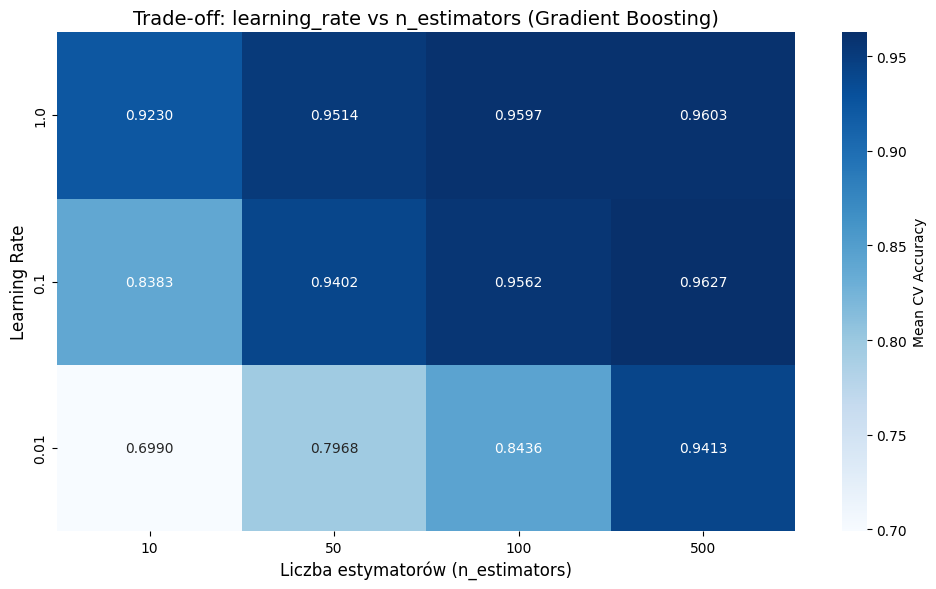

In [19]:
gb_grid = trained_models['Gradient_Boosting']

results = pd.DataFrame(gb_grid.cv_results_)

scores = results[['param_learning_rate', 'param_n_estimators', 'mean_test_score']].copy()

scores['param_learning_rate'] = scores['param_learning_rate'].astype(float)
scores['param_n_estimators'] = scores['param_n_estimators'].astype(int)

pivot_table = scores.pivot(index='param_learning_rate', columns='param_n_estimators', values='mean_test_score')

plt.figure(figsize=(10, 6))
sns.heatmap(pivot_table, annot=True, cmap='Blues', fmt=".4f", cbar_kws={'label': 'Mean CV Accuracy'})
plt.title('Trade-off: learning_rate vs n_estimators (Gradient Boosting)', fontsize=14)
plt.ylabel('Learning Rate', fontsize=12)
plt.xlabel('Liczba estymatorów (n_estimators)', fontsize=12)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

**Stacking**

In [20]:
# Stacking z regresją logistyczną w 1 warstwie
basic_models = [
    ('log_reg', LogisticRegression(max_iter=1000, random_state=42)),
]

meta_model = LogisticRegression(max_iter=1000, random_state=42)

stacking = StackingClassifier(estimators=basic_models, final_estimator=meta_model, cv=5)
stacking.fit(X_train, y_train)

y_pred = stacking.predict(X_test)

evaluate_model("STACKING", stacking, X_test, y_test)


RAPORT DLA MODELU: STACKING
Czas predykcji: 0.00370 sekund

Dokładność (Accuracy): 0.9031

Szczegółowy raport klasyfikacji:
                     precision    recall  f1-score   support

Insufficient_Weight       0.88      1.00      0.93        56
      Normal_Weight       0.92      0.71      0.80        62
     Obesity_Type_I       0.95      0.92      0.94        78
    Obesity_Type_II       0.92      0.97      0.94        58
   Obesity_Type_III       1.00      1.00      1.00        63
 Overweight_Level_I       0.81      0.82      0.81        56
Overweight_Level_II       0.83      0.90      0.87        50

           accuracy                           0.90       423
          macro avg       0.90      0.90      0.90       423
       weighted avg       0.91      0.90      0.90       423


Pewność modelu (Confidence) dla 3 pierwszych pacjentów testowych:
Pacjent 1: diagnoza 'Insufficient_Weight' z pewnością 96.8%
Pacjent 2: diagnoza 'Obesity_Type_III' z pewnością 97.7%
Pacjent 3: diagno

In [21]:
# Stacking z drzewami decyzyjnymi w 1 warstwie
basic_models = [
    ('single_tree', DecisionTreeClassifier(random_state=42)),
]

meta_model = LogisticRegression(max_iter=1000, random_state=42)

stacking = StackingClassifier(estimators=basic_models, final_estimator=meta_model, cv=5)
stacking.fit(X_train, y_train)

y_pred = stacking.predict(X_test)

evaluate_model("STACKING", stacking, X_test, y_test)


RAPORT DLA MODELU: STACKING
Czas predykcji: 0.00360 sekund

Dokładność (Accuracy): 0.9480

Szczegółowy raport klasyfikacji:
                     precision    recall  f1-score   support

Insufficient_Weight       0.93      0.98      0.96        56
      Normal_Weight       0.92      0.89      0.90        62
     Obesity_Type_I       0.96      0.96      0.96        78
    Obesity_Type_II       0.96      0.95      0.96        58
   Obesity_Type_III       1.00      1.00      1.00        63
 Overweight_Level_I       0.89      0.91      0.90        56
Overweight_Level_II       0.96      0.94      0.95        50

           accuracy                           0.95       423
          macro avg       0.95      0.95      0.95       423
       weighted avg       0.95      0.95      0.95       423


Pewność modelu (Confidence) dla 3 pierwszych pacjentów testowych:
Pacjent 1: diagnoza 'Insufficient_Weight' z pewnością 92.0%
Pacjent 2: diagnoza 'Obesity_Type_III' z pewnością 97.6%
Pacjent 3: diagno

In [22]:
# Stacking z różnymi modelami w 1 warstwie
basic_models = [
    ('log_reg', LogisticRegression(max_iter=1000, random_state=42)),
    ('single_tree', DecisionTreeClassifier(random_state=42)),
    ('single_tree_3', DecisionTreeClassifier(random_state=42, max_depth=3)),
]

meta_model = LogisticRegression(max_iter=1000, random_state=42)

stacking = StackingClassifier(estimators=basic_models, final_estimator=meta_model, cv=5)
stacking.fit(X_train, y_train)

y_pred = stacking.predict(X_test)

evaluate_model("STACKING", stacking, X_test, y_test)


RAPORT DLA MODELU: STACKING
Czas predykcji: 0.00736 sekund

Dokładność (Accuracy): 0.9527

Szczegółowy raport klasyfikacji:
                     precision    recall  f1-score   support

Insufficient_Weight       0.96      0.98      0.97        56
      Normal_Weight       0.90      0.92      0.91        62
     Obesity_Type_I       0.96      0.96      0.96        78
    Obesity_Type_II       0.96      0.95      0.96        58
   Obesity_Type_III       1.00      1.00      1.00        63
 Overweight_Level_I       0.89      0.91      0.90        56
Overweight_Level_II       0.98      0.94      0.96        50

           accuracy                           0.95       423
          macro avg       0.95      0.95      0.95       423
       weighted avg       0.95      0.95      0.95       423


Pewność modelu (Confidence) dla 3 pierwszych pacjentów testowych:
Pacjent 1: diagnoza 'Insufficient_Weight' z pewnością 98.7%
Pacjent 2: diagnoza 'Obesity_Type_III' z pewnością 99.0%
Pacjent 3: diagno

**Voting**

In [23]:
basic_models_voting = [
    ('log_reg', LogisticRegression(max_iter=1000, random_state=42)),
    ('decision_tree', DecisionTreeClassifier(random_state=42, max_depth=5))
]

voting_clf = VotingClassifier(estimators=basic_models_voting, voting='soft')
voting_clf.fit(X_train, y_train)

evaluate_model("VOTING CLASSIFIER (Soft)", voting_clf, X_test, y_test)


RAPORT DLA MODELU: VOTING CLASSIFIER (Soft)
Czas predykcji: 0.00751 sekund

Dokładność (Accuracy): 0.8865

Szczegółowy raport klasyfikacji:
                     precision    recall  f1-score   support

Insufficient_Weight       0.90      0.93      0.91        56
      Normal_Weight       0.85      0.71      0.77        62
     Obesity_Type_I       0.89      0.94      0.91        78
    Obesity_Type_II       0.97      0.97      0.97        58
   Obesity_Type_III       1.00      1.00      1.00        63
 Overweight_Level_I       0.78      0.80      0.79        56
Overweight_Level_II       0.81      0.84      0.82        50

           accuracy                           0.89       423
          macro avg       0.88      0.88      0.88       423
       weighted avg       0.89      0.89      0.89       423


Pewność modelu (Confidence) dla 3 pierwszych pacjentów testowych:
Pacjent 1: diagnoza 'Insufficient_Weight' z pewnością 94.8%
Pacjent 2: diagnoza 'Obesity_Type_III' z pewnością 99.3%
P

# **3. WALIDACJA WYNIKÓW**

Teraz pora ocenić modele pod kątem ich zastosowania w Meksykańskich szpitalach

In [24]:
def plot_confusion_matrix(nazwa_modelu, model, X_test, y_test):
    y_pred = model.predict(X_test)

    cm = confusion_matrix(y_test, y_pred)

    classes = sorted(y_test.unique())

    plt.figure(figsize=(10, 7))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Reds',
                xticklabels=classes, yticklabels=classes,
                cbar_kws={'label': 'Liczba pacjentów'})

    plt.title(f'Macierz Pomyłek - {nazwa_modelu}', fontsize=14, fontweight='bold')
    plt.ylabel('Prawdziwa diagnoza pacjenta (Rzeczywistość)', fontsize=12)
    plt.xlabel('Diagnoza przewidziana przez model', fontsize=12)
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

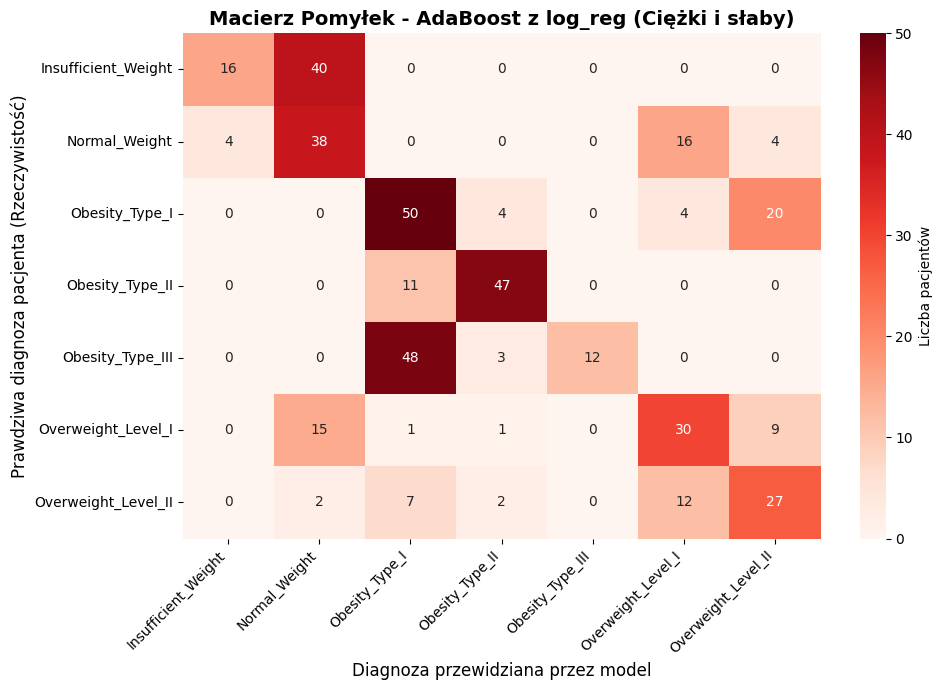

In [25]:
log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train, y_train)

boosting_log_regc = AdaBoostClassifier(estimator=log_reg, random_state=42)
boosting_log_regc.fit(X_train, y_train)

plot_confusion_matrix("AdaBoost z log_reg (Ciężki i słaby)", boosting_log_regc, X_test, y_test)

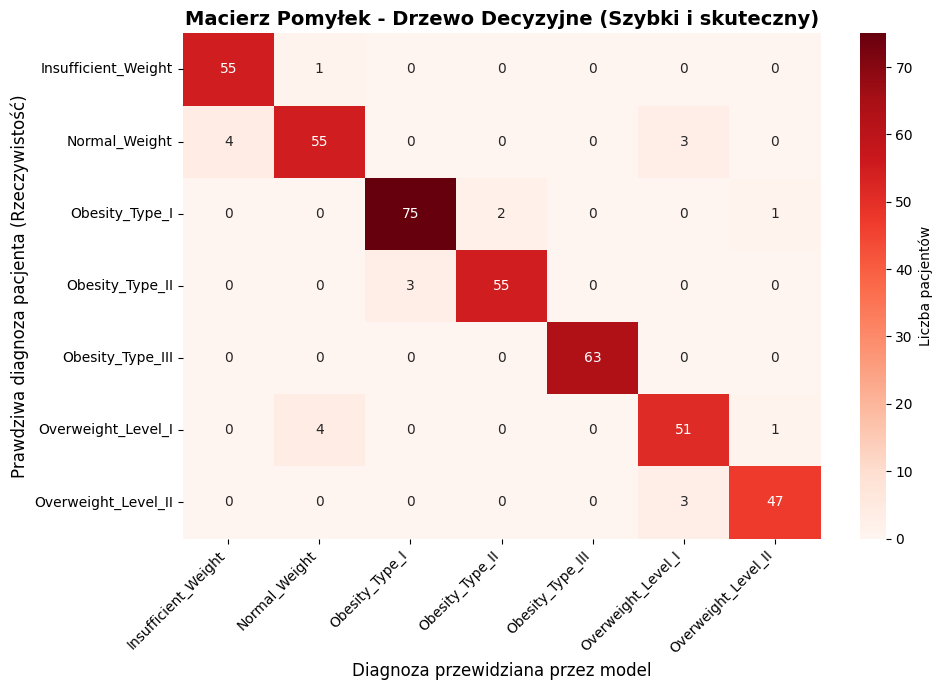

In [31]:
decision_tree = DecisionTreeClassifier(random_state=42)
decision_tree.fit(X_train, y_train)

plot_confusion_matrix("Drzewo Decyzyjne (Szybki i skuteczny)", decision_tree, X_test, y_test)

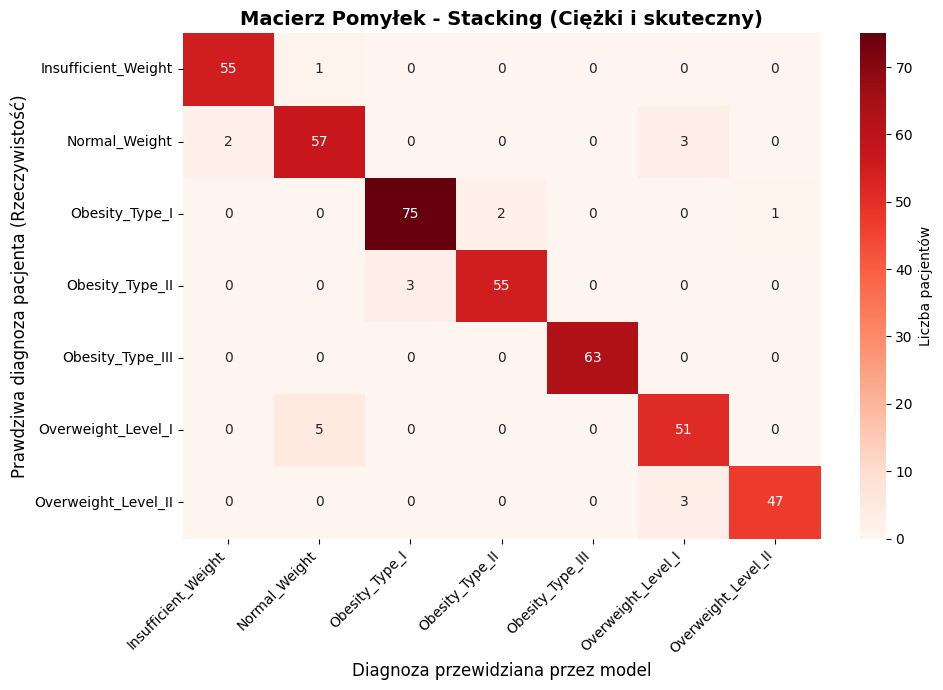

In [32]:
stacking = StackingClassifier(estimators=basic_models, final_estimator=meta_model, cv=5)
stacking.fit(X_train, y_train)

plot_confusion_matrix("Stacking (Ciężki i skuteczny)", stacking, X_test, y_test)

**Tabela Zbiorcza - Wyniki Modeli**

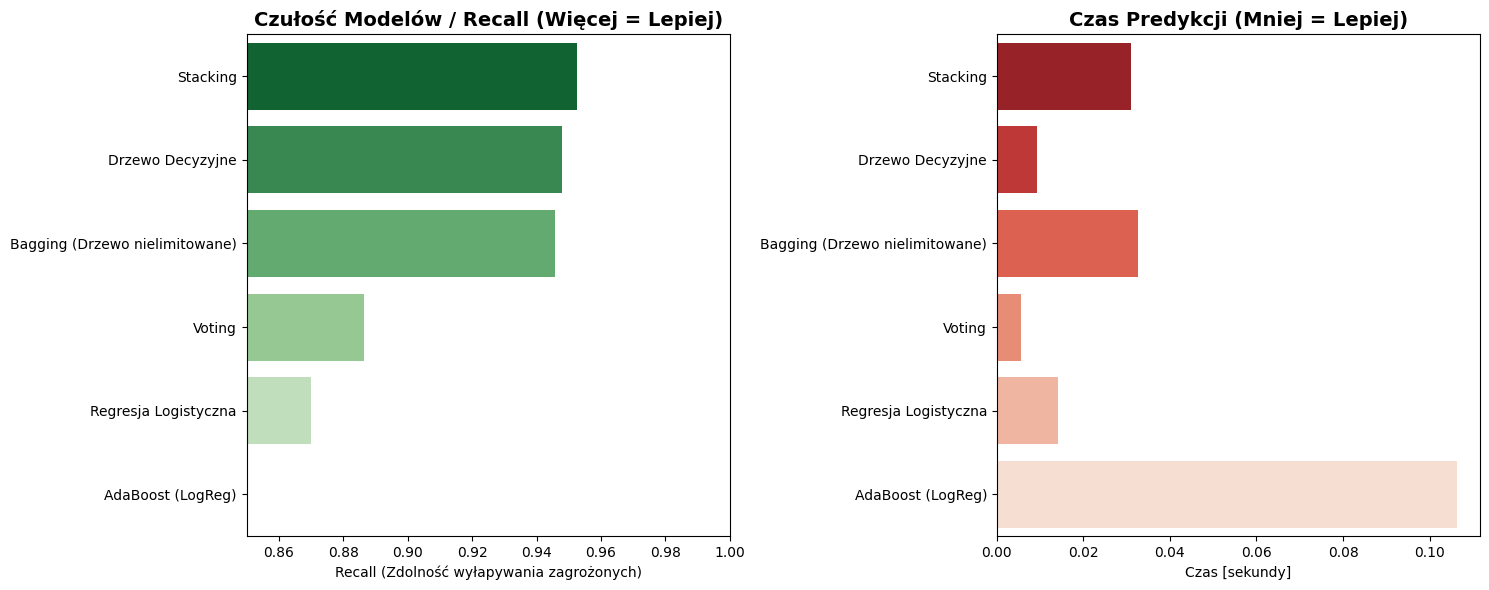


-----------------------------------------------------------------
TABELA ZBIORCZA: PORÓWNANIE SKUTECZNOŚCI (RECALL) I CZASU PREDYKCJI
-----------------------------------------------------------------


,Algorytm,Dokładność (Accuracy),Czułość (Recall),Czas predykcji [s]
0,Stacking,95.27%,95.27%,0.03106
1,Drzewo Decyzyjne,94.80%,94.80%,0.00920
2,Bagging (Drzewo nielimitowane),94.56%,94.56%,0.03261
3,Voting,88.65%,88.65%,0.00570
4,Regresja Logistyczna,87.00%,87.00%,0.01409
5,AdaBoost (LogReg),52.01%,52.01%,0.10632


In [36]:
all_models = {
    "Regresja Logistyczna": log_reg,
    "Drzewo Decyzyjne": decision_tree,
    "Bagging (Drzewo nielimitowane)": unlimited_tree_bagging,
    "AdaBoost (LogReg)": boosting_log_regc,
    "Stacking": stacking,
    "Voting": voting_clf
}

results = []

for name, model in all_models.items():
    start_time = time.time()
    y_pred = model.predict(X_test)
    czas_predykcji = time.time() - start_time

    acc = accuracy_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred, average='weighted')

    results.append({
        "Algorytm": name,
        "Dokładność (Accuracy)": acc,
        "Czułość (Recall)": rec,
        "Czas predykcji [s]": czas_predykcji
    })

df_podsumowanie = pd.DataFrame(results)

df_podsumowanie = df_podsumowanie.sort_values(by="Czułość (Recall)", ascending=False).reset_index(drop=True)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

sns.barplot(data=df_podsumowanie, x='Czułość (Recall)', y='Algorytm', ax=axes[0], palette='Greens_r', hue='Algorytm', legend=False)
axes[0].set_title('Czułość Modelów / Recall (Więcej = Lepiej)', fontsize=14, fontweight='bold')
axes[0].set_xlim(0.85, 1.0)
axes[0].set_xlabel('Recall (Zdolność wyłapywania zagrożonych)')
axes[0].set_ylabel('')

sns.barplot(data=df_podsumowanie, x='Czas predykcji [s]', y='Algorytm', ax=axes[1], palette='Reds_r', hue='Algorytm', legend=False)
axes[1].set_title('Czas Predykcji (Mniej = Lepiej)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Czas [sekundy]')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

df_podsumowanie['Dokładność (Accuracy)'] = df_podsumowanie['Dokładność (Accuracy)'].apply(lambda x: f"{x*100:.2f}%")
df_podsumowanie['Czułość (Recall)'] = df_podsumowanie['Czułość (Recall)'].apply(lambda x: f"{x*100:.2f}%")
df_podsumowanie['Czas predykcji [s]'] = df_podsumowanie['Czas predykcji [s]'].apply(lambda x: f"{x:.5f}")

print("\n" + 65*"-")
print("TABELA ZBIORCZA: PORÓWNANIE SKUTECZNOŚCI (RECALL) I CZASU PREDYKCJI")
print(65*"-")
display(df_podsumowanie)

# **4. Wnioski dla Ministerstwa Zdrowia**

Przetestowałem kilkanaście modeli i najlepszym modelem pod względem do wdrożenia przez MZ okazało się **pojedyncze drzewo decyzyjne**.

Osiąga ono Accuracy i Recaall na poziomie 95%. Do tego jest to zdecydowanie najszybszy model.

Drzewo decyzyjne jest też dobrze wyjaśnialną metodą, lekarz będzie mógł zobaczyć na jego wizualizację i dowiedzieć się dlaczego podjął jaką decyzję.

Możemy też zauważyć, że pewność decyzji w raporcie dla 3 pierwszych pacjentów drzewa była równa 100%.

Pod względem osiągów nieznacznie przegonił go **Stacking** ale jest to model, który wymagał zdecydowanie więcej czasu, więc wdrożenie go do słabych, wiejskich systemów byłoby ryzykowne.

Zdecydowanie najgorszym modelem był **AdaBoost** z regresją logistyczną w środku. Nie dość, że osiągał wyniki podobne do losowego zgadywania, to jeszcze czas predykcji był zdecydowanie najdłuższy.